In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.linear_model
import sklearn.metrics

In [5]:
cancer_data = sklearn.datasets.load_breast_cancer(as_frame=True)
df = cancer_data.frame

df = df.rename(columns={'target': 'Outcome'})

print("Dataset loaded successfully. Displaying first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying first 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [8]:
# 1. Missing Values
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

# 2. Duplicates
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Total missing values: 0
Total duplicate rows: 0


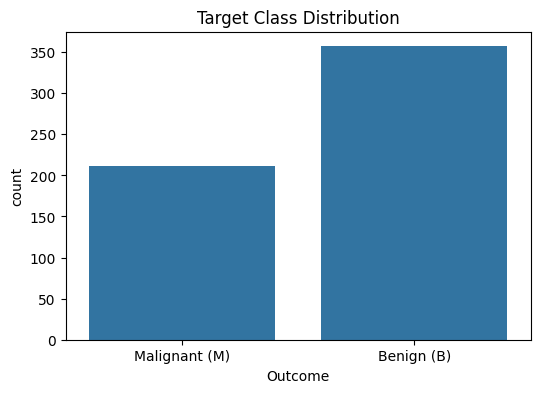

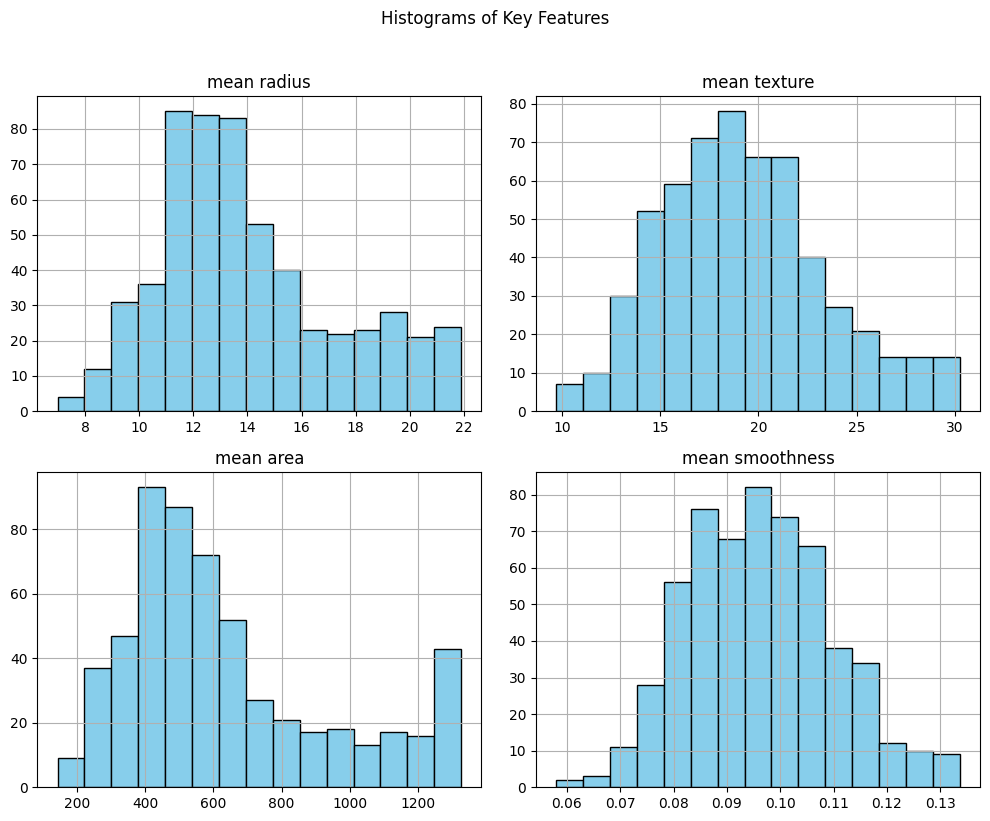

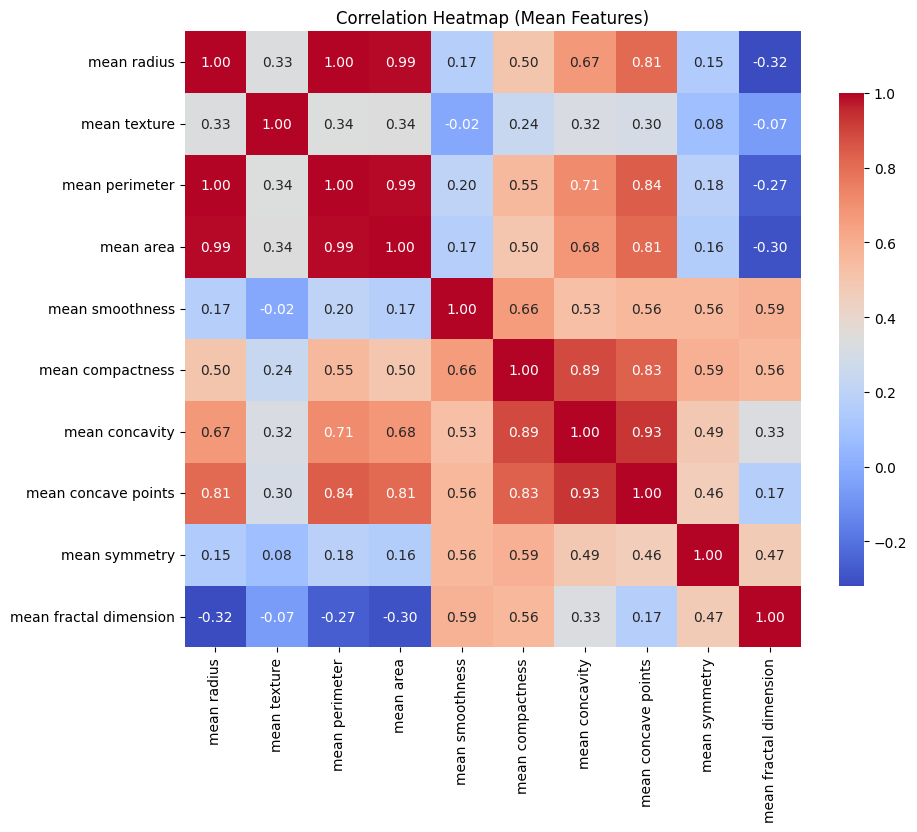

In [10]:
# Plot 1: Class Distribution
plt.figure(figsize=(6, 4))
# Map the numeric targets back to strings just for the plot (0: Malignant, 1: Benign in sklearn)
plot_df = df.copy()
plot_df['Outcome'] = plot_df['Outcome'].map({0: 'Malignant (M)', 1: 'Benign (B)'})
sns.countplot(data=plot_df, x='Outcome')
plt.title('Target Class Distribution')
plt.show()

# Plot 2: Histograms for key features (sklearn uses spaces instead of underscores)
key_features = ['mean radius', 'mean texture', 'mean area', 'mean smoothness']
df[key_features].hist(bins=15, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Key Features', y=1.02)
plt.tight_layout()
plt.show()

# Plot 3: Correlation Heatmap (Taking subset of mean features for readability)
plt.figure(figsize=(10, 8))
mean_features = [col for col in df.columns if 'mean' in col]
corr_matrix = df[mean_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap (Mean Features)')
plt.show()


Task 2: Data Preprocessing


In [11]:
df['Outcome'] = 1 - df['Outcome']
print("Target variable encoded: Malignant mapped to 1, Benign mapped to 0.")

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

Target variable encoded: Malignant mapped to 1, Benign mapped to 0.


In [12]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
print(f"Data split 80/20. Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Data split 80/20. Training samples: 455, Testing samples: 114


In [14]:
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized")

Features standardized


Task 3: Model Training and Basic Evaluation


In [15]:
log_reg = sklearn.linear_model.LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully.")

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class (1)

Logistic Regression model trained successfully.


In [17]:
acc = sklearn.metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1 for both classes
print("Classification Report (Precision, Recall, F1-Score):")
print(sklearn.metrics.classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


Accuracy: 0.9649
Classification Report (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



Confusion Matrix


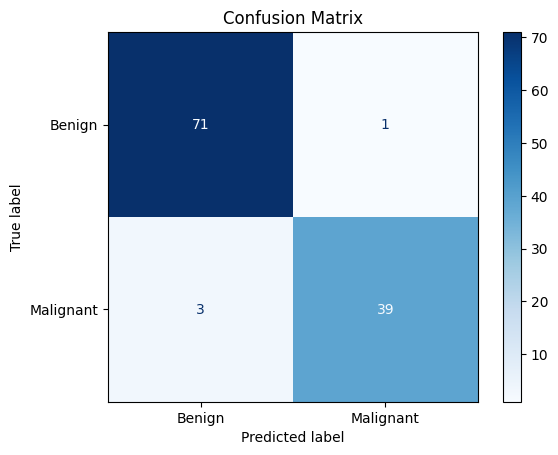

ROC Curve and AUC


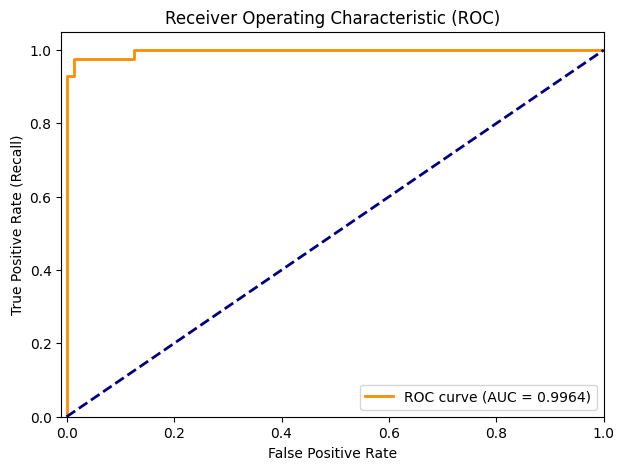

In [18]:
print("Confusion Matrix")
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve and AUC Score
print("ROC Curve and AUC")
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_pred_proba)
roc_auc = sklearn.metrics.auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()